# **Handling Data Imbalance**
---
## Notebook Overview
This notebook is divided into two parts. In first part, traditional methods are used to tackle data imbalance. In second part, built in library **imblearn** is used to tackle data imbalance. Performance of the linear regession model is compared on original and balanced data obtained using various methods.
1. **Basic methods**
2. **Built-in algorithmic methods**

---

## Understanding Data Imbalance
In a dataset when one of the class occur predominantly than other classes, the dataset is imbalanced. Most of the real world datasets are imbalanced. It appears in many domains, including fraud detection, spam filtering, disease screening,advertising click-throughs, etc.


> #### **Problem with Imbalanced Dataset :**
 Imbalanced data hamper the performance of the model trained on them. Though the model tend to show high accuracy during training, it fails miserably when deployed (*Accuracy Paradox*). For example, if one of the class forms 99% of the dataset, then in such case any basic classification model may get a pretty high accuracy just by predicting the majority class and fail to capture the minority class.

## How to tackle Data Imbalance ?
"Can we Collect More Data?" - Certainly it is not possible or observation time for collecting more data is long. Luckly we have few methods as listed below to address data imbalance problem. Detail explaination of each method is given in corresponding part.
> #### **Basic Methods**:
> 1. Random OverSampling of Minority Class
> 2. Random UnderSampling of Minority Class

> #### **Built-in algorithmic methods**:
> 1. Under-Sampling: Tomek Links
> 2. Synthetic Minority Oversampling Technique (SMOTE)
> 3. Over-sampling using SMOTE and cleaning using ENN



## Notebook Starter

In [62]:
# Importing necessary libraries
# General Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ML library
from sklearn import model_selection
from sklearn import linear_model
from sklearn import metrics
from sklearn import linear_model

# Data Balancing Library
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# regression-multiple-methods.ipynb

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Loading Data and Data Summary

In [72]:
metric_table = pd.DataFrame()
# To ensure reproducibility
# Algorithms

algorithms = {
        'Linear Regression': LinearRegression(),
        'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
        'RandomForest': RandomForestRegressor(),
        'XGBoost': GradientBoostingRegressor(),
        'knn': KNeighborsRegressor(),
        'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
    }
file_path = 'curse-of-dimensionality.xlsx'
np.random.seed(42)
# load the dataset
xls = pd.ExcelFile(file_path)

In [74]:
def trainAndTestWithSampling(X, y, strategy, use_strag, model, model_name):
  np.random.seed(5)
  # split into train/test sets with same class ratio
  trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2,random_state=42)

  #Apply sampling technique if any
  if use_strag:
    trainX, trainy = strategy.fit_resample(trainX, trainy)
  # define model
  # fit model
  model.fit(trainX, trainy)
  # predict on test set
  yhat = model.predict(trainX)
  # evaluate predictions
  r2_train = model.score(trainX, trainy)
  rmse_train = root_mean_squared_error(trainy, yhat)
  residuals_train = trainy - yhat
  
  # predict on test set
  yhat_test = model.predict(testX)
  # evaluate predictions
  r2_test = model.score(testX, testy)
  rmse_test = root_mean_squared_error(testy, yhat_test)
  residuals_test = testy - yhat_test
  metric_table.at[model_name, 'R-squared Train'] = r2_train
  metric_table.at[model_name, 'RMSE Train'] = rmse_train
  metric_table.at[model_name, 'R-squared Test'] = r2_test
  metric_table.at[model_name, 'RMSE Test'] = rmse_test
  return trainX, testX, trainy, testy

In [75]:
def calculate_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["feature"] = dataframe.columns
    # calculating VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i) for i in range(len(dataframe.columns))]
    return vif_data

In [76]:
# 2. Iterative VIF Reduction Loop
vif_threshold = 5.0 # Set your desired threshold
metrics_history = []
dropped_features = []

def progressive_vif_analysis(X_current, X_test_current, trainy, testy, algorithm):
    while True:
        vif_results = calculate_vif(X_current)
        # Exclude the intercept from VIF check for dropping features
        highest_vif_feature = vif_results[vif_results['feature'] != 'intercept'].sort_values(by='VIF', ascending=False).iloc[0]
        
        if highest_vif_feature['VIF'] > vif_threshold:
            feature_to_drop = highest_vif_feature['feature']
            dropped_features.append(feature_to_drop)
            # Drop the feature from both train and test sets
            X_current = X_current.drop(columns=feature_to_drop)
            X_test_current = X_test_current.drop(columns=feature_to_drop)
            # Train model and record metrics *after* the drop
            trainX, testX, trainy, testy, r2_train, rmse_train, residuals_train, r2_test, rmse_test, residuals_test = trainAndTestWithSampling(X_current, X_test_current,False,False, algorithm)
        else:
            print(f"\nAll remaining features have VIF below threshold of {vif_threshold}.")
            break                       

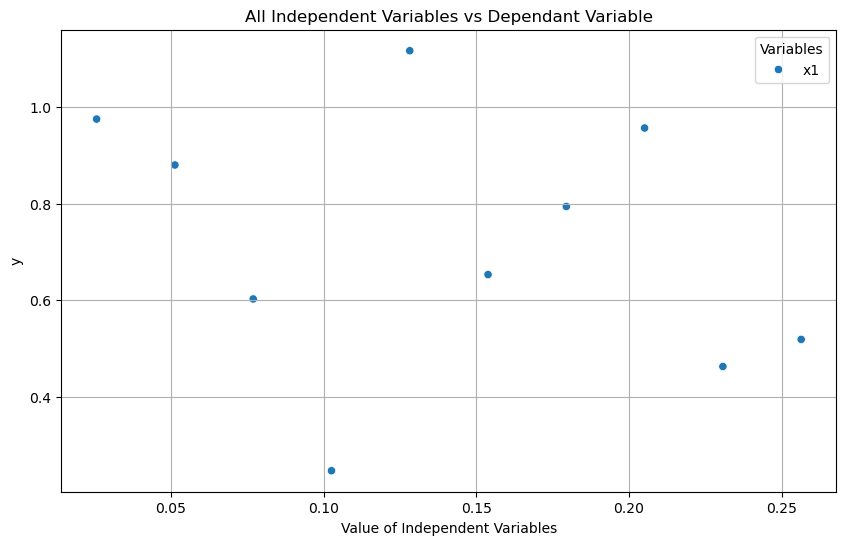

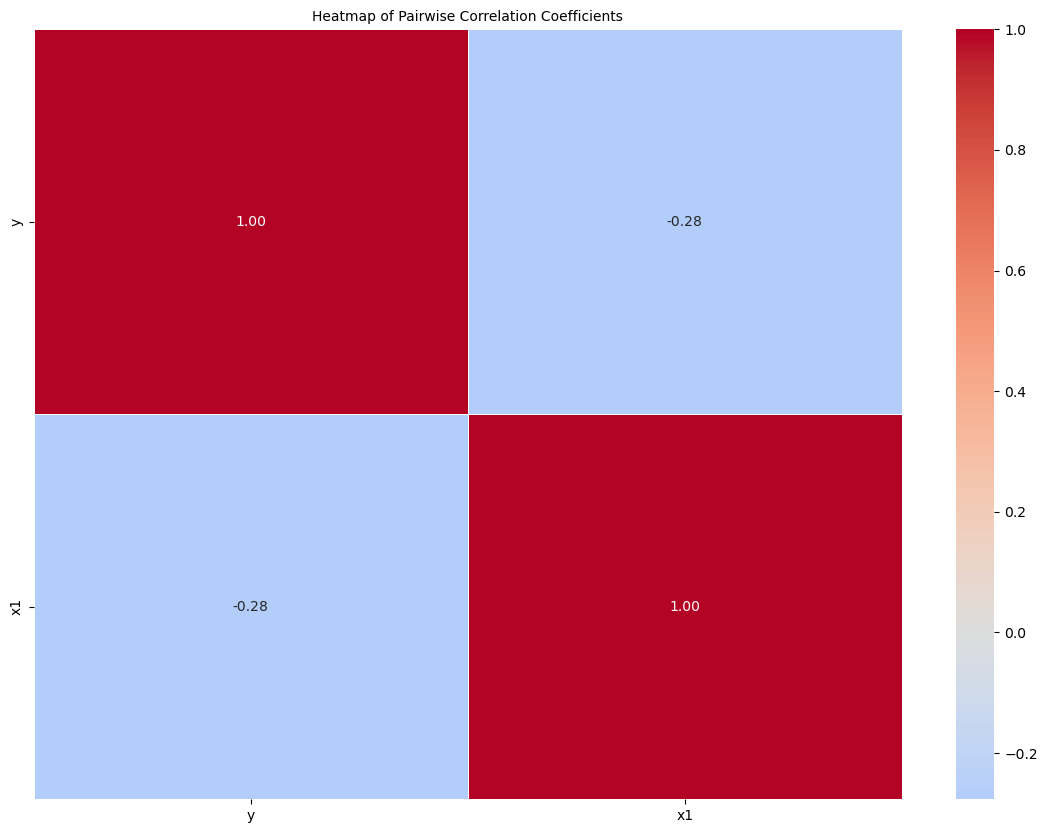

     feature       VIF
1  intercept  4.666667
0         x1  1.000000
--------------------------------------------------
Metrics Sheet1

                   R-squared Train  RMSE Train  R-squared Test  RMSE Test
Linear Regression         0.010233    0.264268        0.219716   0.184233
SVM Regression           -0.029222    0.269484        0.588272   0.133828
RandomForest              0.620768    0.163580        0.679102   0.118148
XGBoost                   0.999994    0.000658        0.860441   0.077915
knn                      -0.017185    0.267903       -0.666252   0.269223
Neural Network-10        -0.072163    0.275048       -0.057852   0.214513
-------------------------------------------------


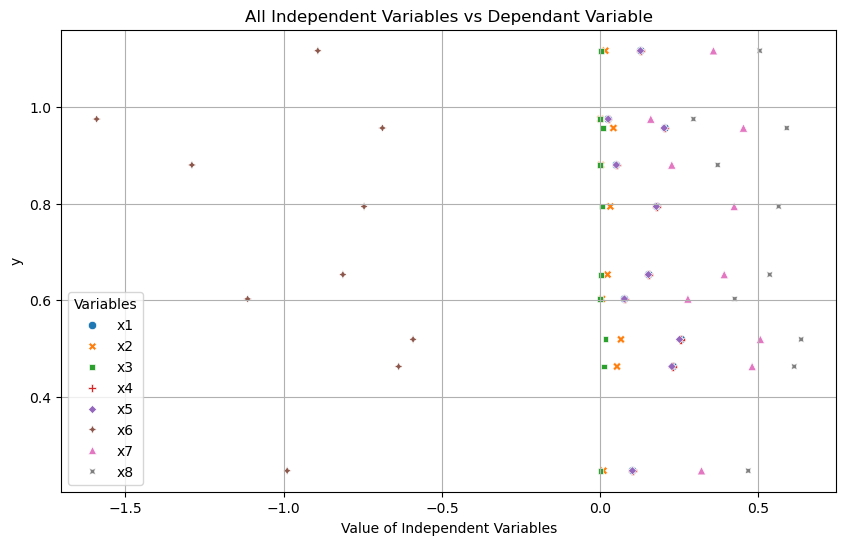

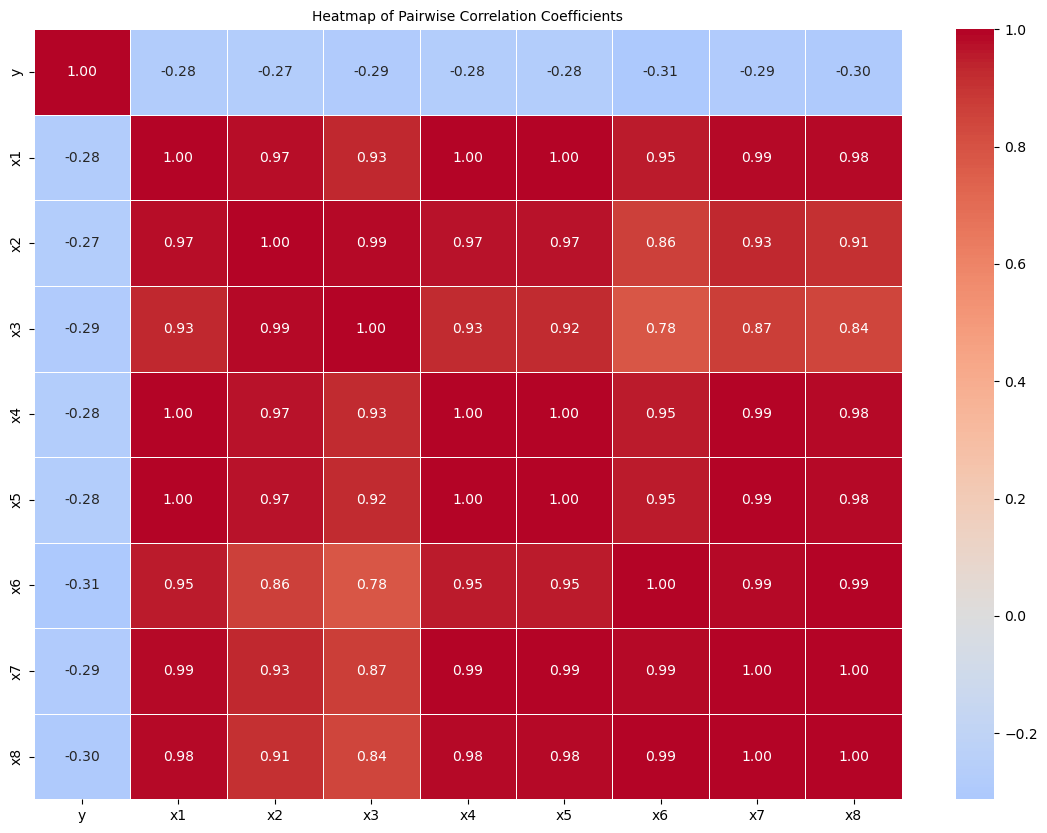

c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


     feature           VIF
0         x1           inf
3         x4           inf
4         x5  9.007199e+15
2         x3  8.188363e+14
8  intercept  3.691475e+13
6         x7  8.627585e+12
7         x8  3.107002e+12
5         x6  1.968830e+11
1         x2  9.583554e+10
--------------------------------------------------
Metrics Sheet2

                   R-squared Train    RMSE Train  R-squared Test  RMSE Test
Linear Regression         1.000000  8.891931e-10   -13072.751903  23.847459
SVM Regression            0.059341  2.576286e-01        0.308075   0.173489
RandomForest              0.681009  1.500262e-01        0.453533   0.154179
XGBoost                   0.999994  6.578797e-04        0.224671   0.183648
knn                      -0.002017  2.658982e-01       -0.666252   0.269223
Neural Network-10        -0.071339  2.749422e-01       -0.075217   0.216267
-------------------------------------------------


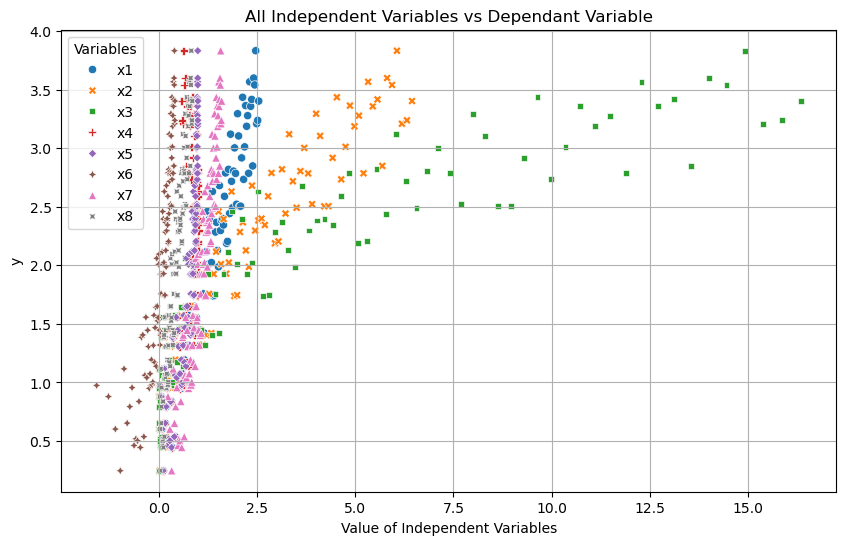

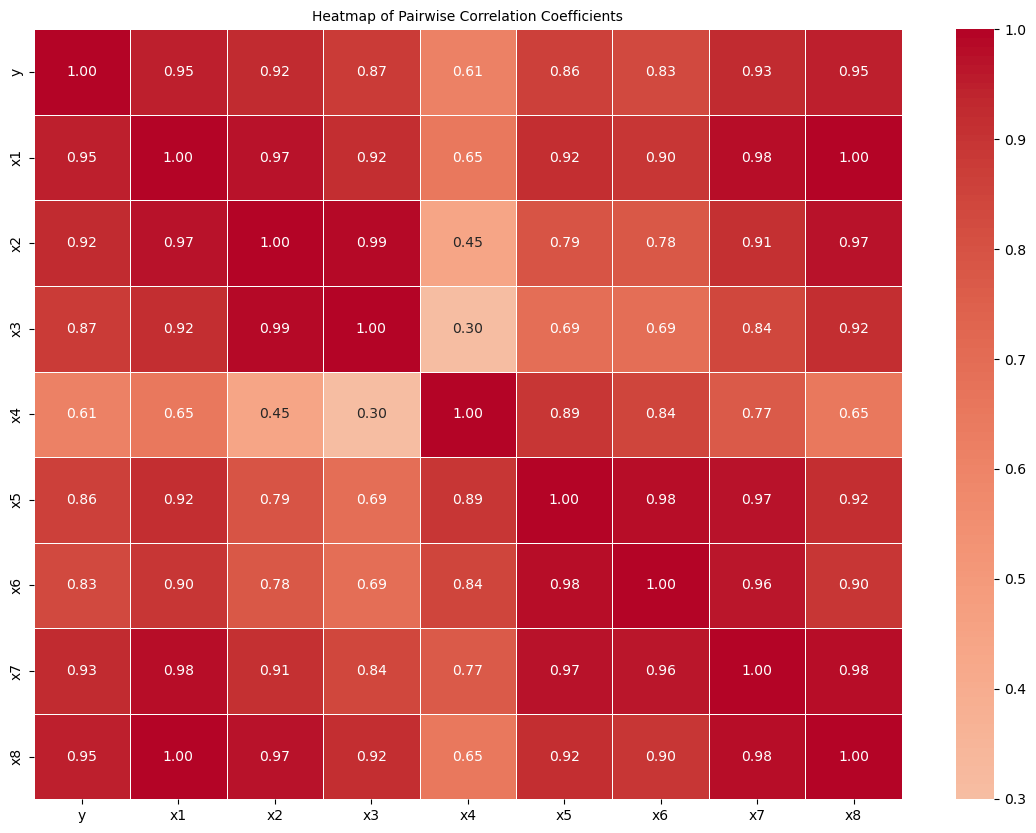

c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


     feature           VIF
0         x1           inf
7         x8           inf
1         x2  1.166248e+07
6         x7  7.996571e+05
8  intercept  7.946015e+05
2         x3  7.298874e+05
4         x5  2.554343e+05
3         x4  8.281459e+04
5         x6  2.083295e+04
--------------------------------------------------
Metrics Sheet3

                   R-squared Train  RMSE Train  R-squared Test  RMSE Test
Linear Regression         0.909080    0.267606        0.637927   0.577127
SVM Regression            0.782515    0.413886        0.767424   0.462548
RandomForest              0.979361    0.127499        0.854212   0.366214
XGBoost                   0.988335    0.095854        0.852262   0.368655
knn                       0.910651    0.265284        0.864742   0.352740
Neural Network-10         0.892769    0.290621        0.870950   0.344550
-------------------------------------------------


In [ ]:
for sheet_name in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    X = df.drop(columns=['y'])
    # Note: VIF analysis requires a constant/intercept term to be included
    X['intercept'] = 1
    y = df['y']
    target_var = 'y'
    independent_vars = [col for col in df.columns if col != target_var]

    # --- Reshape the DataFrame into "long" format ---
    # We use melt() to stack the independent variables into a single 'X_Value' column,
    # while keeping the 'y' value repeated for each entry.
    df_long = df.melt(
        id_vars=[target_var],
        value_vars=independent_vars,
        var_name='Independent_Variable',
        value_name='X_Value'
    )

    # --- Create the single scatter plot using Seaborn ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_long,
        x='X_Value',          # All X values combined here
        y=target_var,         # The common Y value
        hue='Independent_Variable', # Differentiate variables by color
        style='Independent_Variable' # Differentiate variables by marker shape
    )

    plt.title('All Independent Variables vs Dependant Variable')
    plt.xlabel('Value of Independent Variables')
    plt.ylabel(target_var)
    plt.legend(title='Variables')
    plt.grid(True)
    plt.show()
    
    # b. Heatmap
    corr = df.select_dtypes(include='number').corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Heatmap of Pairwise Correlation Coefficients', fontsize=10)
    plt.show()
    
    # Run the function
    vif_results = calculate_vif(X)
    # Display results, sorting by VIF value for easier observation
    print(vif_results.sort_values(by='VIF', ascending=False))
    print('-'*50)
    for model_name, algorithm in algorithms.items():
        trainX, testX, trainy, testy = trainAndTestWithSampling(X,y,False,False,algorithm, model_name)

        # Work on a copy of the training data
        X_current = trainX.copy()
        X_test_current = testX.copy()
        progressive_vif_analysis(X_current)

    # Display the metrics' Tables
    print(f"Metrics {sheet_name}\n")
    print(metric_table.to_string())
    print("-------------------------------------------------")


## Basic Methods


### Random OverSampling and UnderSampling

In [5]:
# Random Under Sampling of Majority class
np.random.seed(5)
trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

df = pd.concat([trainX, trainy], axis=1)
class1 = df[df[3] == 1]
class2 = df[df[3] == 2]

class1_count , class2_count = trainy.value_counts()
class1_under = class1.sample(class2_count)

df_under = pd.concat([class1_under, class2], axis=0)

print("Total class of 1 and 2 after Undersampling of majority class: \n",df_under[3].value_counts())
trainXu, trainyu = df_under[[0, 1, 2]], df_under[3]
model = linear_model.LogisticRegression(solver='liblinear')
# fit model
model.fit(trainXu, trainyu)
# predict on test set
yhat = model.predict(testX)
# evaluate predictions
acc_under = metrics.accuracy_score(testy, yhat)
prec_under = metrics.precision_score(testy, yhat)
recall_under = metrics.recall_score(testy, yhat)
f1_score_under = metrics.f1_score(testy, yhat)
print(f'UNDER Sampling: Accuracy:{acc_under}|precision_score:{prec_under}|recall_score:{recall_under}|f1_score:{f1_score_under}')


Total class of 1 and 2 after Undersampling of majority class: 
 3
1    65
2    65
Name: count, dtype: int64
UNDER Sampling: Accuracy:0.6612903225806451|precision_score:0.7659574468085106|recall_score:0.782608695652174|f1_score:0.7741935483870968


In [6]:
# Random Over Sampling of Minority Class
np.random.seed(5)
trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

df = pd.concat([trainX, trainy], axis=1)
class1 = df[df[3] == 1]
class2 = df[df[3] == 2]

class1_count , class2_count = trainy.value_counts()
class2_over = class2.sample(class1_count, replace=True)

df_over = pd.concat([class2_over, class1], axis=0)

print("Total class of 1 and 2 after Oversampling of minority class: \n",df_over[3].value_counts())
trainXo, trainyo = df_over[[0, 1, 2]], df_over[3]
model = linear_model.LogisticRegression(solver='liblinear')
# fit model
model.fit(trainXo, trainyo)
# predict on test set
yhat = model.predict(testX)
# evaluate predictions
acc_over = metrics.accuracy_score(testy, yhat)
prec_over = metrics.precision_score(testy, yhat)
recall_over = metrics.recall_score(testy, yhat)
f1_score_over = metrics.f1_score(testy, yhat)
print(f'UNDER Sampling: Accuracy:{acc_under}|precision_score:{prec_under}|recall_score:{recall_under}|f1_score:{f1_score_under}')

Total class of 1 and 2 after Oversampling of minority class: 
 3
2    179
1    179
Name: count, dtype: int64
UNDER Sampling: Accuracy:0.6612903225806451|precision_score:0.7659574468085106|recall_score:0.782608695652174|f1_score:0.7741935483870968


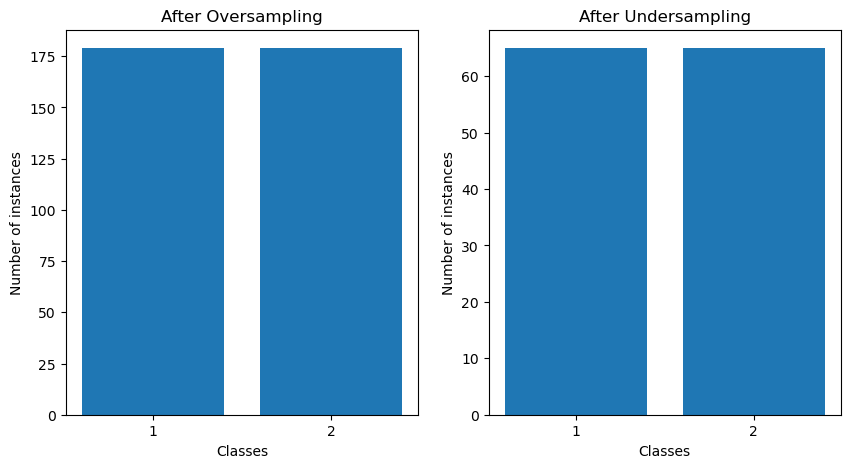

In [7]:
# Plotting
fig, ax = plt.subplots(1, 2,figsize=(10,5))
ax[0].bar(["1", "2"], trainyo.value_counts())
ax[0].set_title("After Oversampling")
ax[0].set(xlabel = "Classes", ylabel = "Number of instances")

ax[1].bar(["1", "2"], trainyu.value_counts())
ax[1].set_title("After Undersampling")
ax[1].set(xlabel = "Classes", ylabel = "Number of instances")

plt.show()

> Popular alternatives for the accuracy are the precision, recall and f1 scores that allow the performance of the model to be considered by focusing on the minority class.




**Result :** Random Oversampling and Undersampling is not much of the help. In case of Random Oversampling, we may tend to overfit minority class. Similarly in case of Random Undersampling, we tend to lose useful information in data.

## Built-in algorithmic methods
1. **Tomek links :** Tomek links are pairs of very close instances but of different classes. This method removes the instances of the majority class of those pairs. Thus undersampling majority class and increasing the space between the different classes which in turn facilitate the classification process.

2. **Synthetic Minority Oversampling Technique (SMOTE) :**This method aims to oversample the minority class. But instead of random oversampling, SMOTE (Synthetic Minority Oversampling Technique) works by randomly picking a point from the minority class and computing the k-nearest neighbors for this point. The synthetic points are added between the chosen point and its neighbors.
3. **Over-sampling using SMOTE and cleaning using ENN :**This method combines the SMOTE ability to generate synthetic examples for minority class and ENN ability to delete some observations. In from both classes that are identified as having different class between the observation’s class and its K-nearest neighbor majority class.

In [8]:
def technique(X,y):

  # summarize class distribution
  print("Original :",Counter(y))

  ### TomekLinks
  undersample = TomekLinks()

  ### SMOTE
  oversample = SMOTE(sampling_strategy=0.5)

  ### SMOTEENN
  sample = SMOTEENN(sampling_strategy=0.5)

  ### Evaluation
  X, y, acc_orig, prec_orig, recall_orig, f1_orig = trainAndTest(X, y,False,False)
  X_over, y_over, acc_over, prec_over, recall_over, f1_over = trainAndTest(X, y, oversample, True )
  X_under, y_under, acc_under, prec_under, recall_under, f1_under = trainAndTest(X, y, undersample, True)
  X_uo, y_uo, acc_both, prec_both, recall_both, f1_both = trainAndTest(X, y, sample, True)

  df_result = pd.DataFrame({
    'Accuracy': [acc_orig, acc_over, acc_under, acc_both],
    'Precision': [prec_orig, prec_over, prec_under, prec_both],
    'Recall': [recall_orig, recall_over, recall_under, recall_both],
    'F1_score': [f1_orig, f1_over, f1_under, f1_both]
  })

  df_result.index = ['Original data', 'SMOTE', 'TomekLinks', 'SMOTEENN']

  ### Plotting

  fig, ax = plt.subplots(2, 2,figsize=(10,10))

  ax[0, 0].bar(["1","2"], y.value_counts())
  ax[0, 0].set_title("Original Dataset")
  ax[0, 1].bar(["1","2"], y_over.value_counts())
  ax[0, 1].set_title("SMOTE")
  ax[1, 0].bar(["1","2"], y_under.value_counts())
  ax[1, 0].set_title("TomekLinks")
  ax[1, 1].bar(["1","2"], y_uo.value_counts())
  ax[1, 1].set_title("SMOTEENN")
  plt.show()

  fig, ax = plt.subplots(2, 2,figsize=(10,10))

  ax[0, 0].scatter(X[0], X[2], c = y)
  ax[0, 0].set_title("Original Dataset")
  ax[0, 1].scatter(X_over[0], X_over[2], c = y_over)
  ax[0, 1].set_title("After Oversampling")
  ax[1, 0].scatter(X_under[0], X_under[2], c = y_under)
  ax[1, 0].set_title("After Undersampling")
  ax[1, 1].scatter(X_uo[0], X_uo[2], c = y_uo)
  ax[1, 1].set_title("After Over and Under sampling")

  plt.show()

  return df_result


Original : Counter({1: 225, 2: 81})


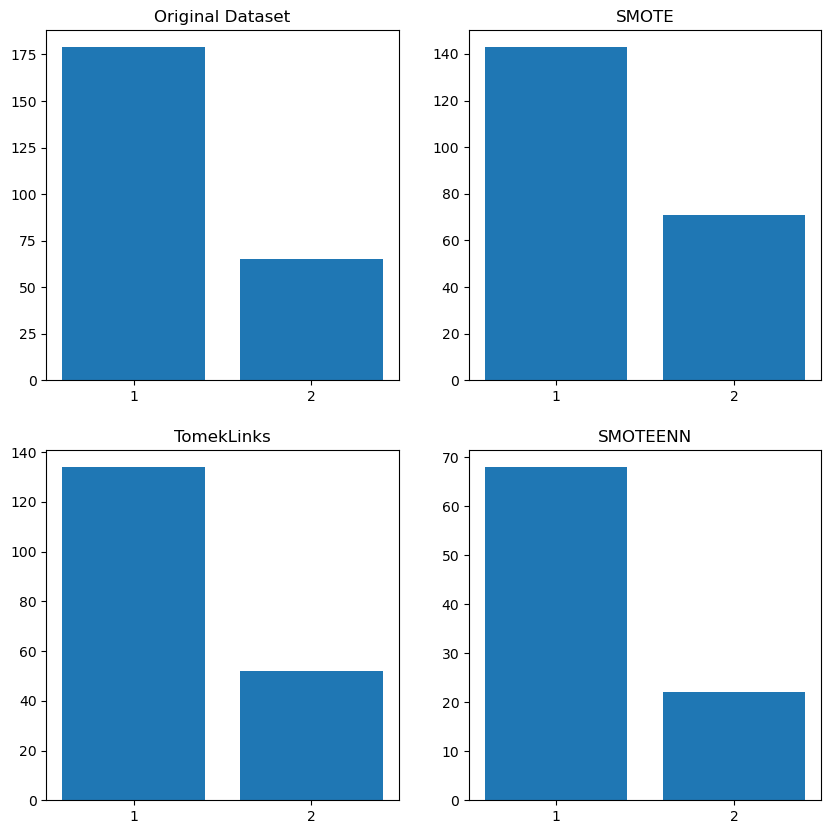

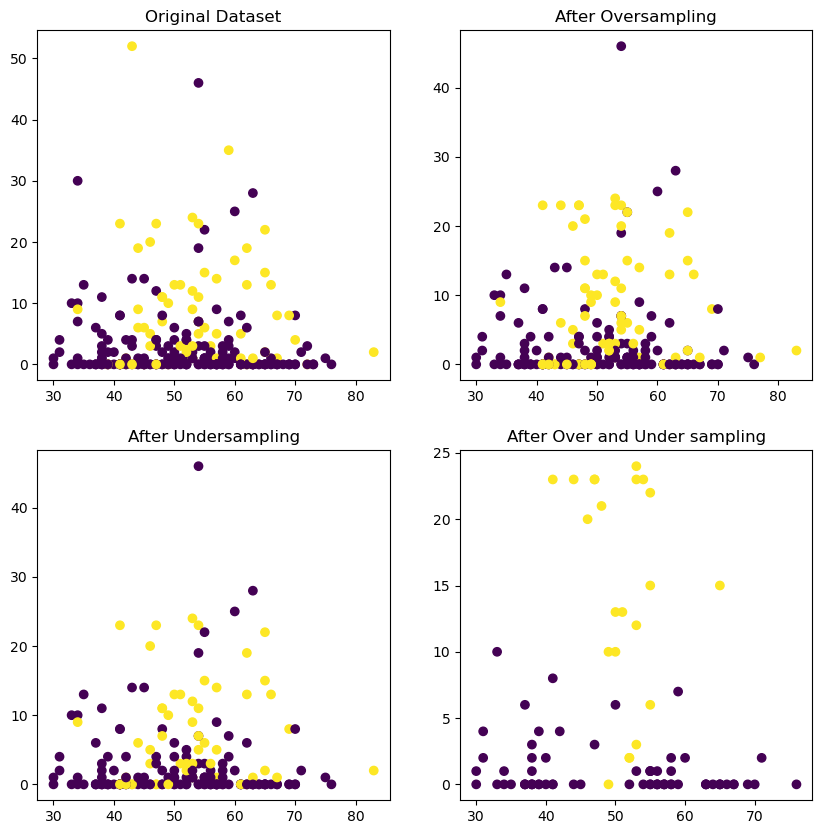

In [9]:
result = technique(X,y)

In [10]:
print("Result Comparision")
result

Result Comparision


,Accuracy,Precision,Recall,F1_score
Original data,0.693548,0.736842,0.913043,0.815534
SMOTE,0.795918,0.795455,0.972222,0.875000
TomekLinks,0.795918,0.795455,0.972222,0.875000
SMOTEENN,0.816327,0.846154,0.916667,0.880000


**Result :**
1. All the built in methods are performing better than the basic methods. Also combined undersampling and oversampling method (SMOTEENN) produces better results compared to just applying either of one.
2. Performing SMOTE+ENN is effective because performing SMOTE alone can lead to the creation of noisy and irrelevant synthetic samples in regions of feature space where the minority class is highly concentrated. This can result in overfitting and reduced generalization performance of the model. SMOTENN (SMOTE-ENN) is a variant of SMOTE that addresses this limitation by combining SMOTE with the Edited Nearest Neighbors (ENN) technique. ENN is a data filtering technique that removes noisy and irrelevant samples from the dataset.


**Note:**
1. Performance of SMOTEENN is affected when there are many outliers or mislabeled examples in the minority class, the edited nearest neighbors step may remove legitimate minority class instances, leading to a loss of valuable information.
2. Built in ML libraries' algorithm have in built method to address the class imbalance problem rather than using external function to address it. Can find the those in resource session.

## References & Further reading:
* [Introduction to Data Imbalance](https://machinelearningmastery.com/what-is-imbalanced-classification/)
* [Other Resource](https://www.analyticsvidhya.com/blog/2020/07/10-techniques-to-deal-with-class-imbalance-in-machine-learning/)
